# Demo: McNemar's Test for Two Models

This notebook simulates **correct/incorrect** outcomes for two hypothetical models on the same test set and demonstrates **McNemar's test** step by step.

McNemar's test is the standard, purpose-built test for **paired binary outcomes** on the same test items. Instead of comparing overall accuracy with an unpaired test, it focuses only on the items where the two models *disagree*.

You can control:
1. test set size `n`
2. baseline accuracy of model B
3. how much more (or less) accurate model A is than model B
4. how strongly the two models' correctness is correlated (shared difficulty of items)


In [1]:
import random

# --- User settings ---
n = 100
acc_b = 0.70          # baseline accuracy of model B
acc_advantage_a = 0.08  # how much more accurate model A is than B (can be negative)
correlation = 0.6     # 0 = independent models, 1 = highly correlated correctness
seed = 42


## 1) Simulate paired binary outcomes

For each test item we draw a shared **difficulty** factor, then decide independently whether each model gets the item right. The `correlation` setting blends each model's outcome toward a shared coin flip, so that easy items tend to be solved by both models and hard items missed by both — just like real paired evaluations.

Each outcome is `1` (correct) or `0` (incorrect).


In [2]:
rng = random.Random(seed)

acc_a = max(0.0, min(1.0, acc_b + acc_advantage_a))

def draw_outcome(p, shared, rho):
    """Blend an independent draw with a shared draw to induce correlation."""
    if rng.random() < rho:
        # Use the shared 'difficulty' draw: item solved iff shared < p
        return 1 if shared < p else 0
    return 1 if rng.random() < p else 0

outcomes_a = []
outcomes_b = []
for _ in range(n):
    shared = rng.random()  # shared difficulty: small = easy item
    a = draw_outcome(acc_a, shared, correlation)
    b = draw_outcome(acc_b, shared, correlation)
    outcomes_a.append(a)
    outcomes_b.append(b)

pairs = list(zip(outcomes_a, outcomes_b))

print(f'Generated {n} paired outcomes.')
print(f'Target accuracy A: {acc_a:.3f}   Target accuracy B: {acc_b:.3f}')
print(f'Observed accuracy A: {sum(outcomes_a)/n:.3f}')
print(f'Observed accuracy B: {sum(outcomes_b)/n:.3f}')
print('First 15 pairs (A, B):', pairs[:15])


Generated 100 paired outcomes.
Target accuracy A: 0.780   Target accuracy B: 0.700
Observed accuracy A: 0.820
Observed accuracy B: 0.680
First 15 pairs (A, B): [(1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 0), (1, 1), (1, 1), (1, 1), (1, 0)]


## 2) Build the 2×2 contingency table

McNemar's test summarizes the paired outcomes in a 2×2 table of counts:

|              | **B correct** | **B wrong** |
|--------------|:-------------:|:-----------:|
| **A correct**|      `a`      |     `b`     |
| **A wrong**  |      `c`      |     `d`     |

- `a` = both correct (concordant)
- `d` = both wrong (concordant)
- `b` = **A correct, B wrong** (discordant)
- `c` = **A wrong, B correct** (discordant)

Only the **discordant** cells `b` and `c` carry information about which model is better. The concordant cells `a` and `d` are ignored by the test.


In [3]:
a = sum(1 for x, y in pairs if x == 1 and y == 1)  # both correct
b = sum(1 for x, y in pairs if x == 1 and y == 0)  # A correct, B wrong
c = sum(1 for x, y in pairs if x == 0 and y == 1)  # A wrong,  B correct
d = sum(1 for x, y in pairs if x == 0 and y == 0)  # both wrong

print('Contingency table (counts):')
print(f"{'':>12}{'B correct':>12}{'B wrong':>12}")
print(f"{'A correct':>12}{a:>12}{b:>12}")
print(f"{'A wrong':>12}{c:>12}{d:>12}")
print()
print(f'Concordant (ignored): a = {a}, d = {d}')
print(f'Discordant (used)   : b = {b} (A>B), c = {c} (B>A)')
print(f'Total discordant pairs: b + c = {b + c}')


Contingency table (counts):
               B correct     B wrong
   A correct          60          22
     A wrong           8          10

Concordant (ignored): a = 60, d = 10
Discordant (used)   : b = 22 (A>B), c = 8 (B>A)
Total discordant pairs: b + c = 30


## 3) Visualize the contingency table and discordant pairs

These plots build intuition before computing the test statistic:
- **Left:** the 2×2 table as a heatmap, highlighting concordant vs discordant cells
- **Right:** the two discordant counts `b` and `c` side by side — McNemar's test asks whether these two are meaningfully imbalanced


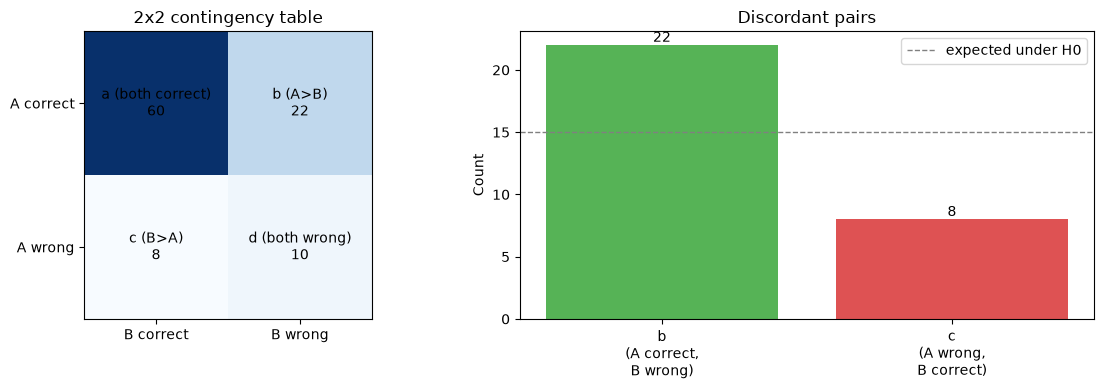

In [4]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

if plt is None:
    print('Matplotlib not installed in this environment; install from requirements.txt to see plots.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot 1: 2x2 contingency heatmap
    table = [[a, b], [c, d]]
    ax = axes[0]
    im = ax.imshow(table, cmap='Blues')
    ax.set_xticks([0, 1], ['B correct', 'B wrong'])
    ax.set_yticks([0, 1], ['A correct', 'A wrong'])
    ax.set_title('2x2 contingency table')
    labels = [['a (both correct)', 'b (A>B)'], ['c (B>A)', 'd (both wrong)']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{table[i][j]}",
                    ha='center', va='center', color='black')

    # Plot 2: discordant counts
    ax = axes[1]
    bars = ax.bar(['b\n(A correct,\nB wrong)', 'c\n(A wrong,\nB correct)'],
                  [b, c], color=['tab:green', 'tab:red'], alpha=0.8)
    ax.set_title('Discordant pairs')
    ax.set_ylabel('Count')
    ax.axhline((b + c) / 2, color='gray', linestyle='--', linewidth=1,
               label='expected under H0')
    for rect, val in zip(bars, [b, c]):
        ax.text(rect.get_x() + rect.get_width() / 2, val, str(val),
                ha='center', va='bottom')
    ax.legend()

    plt.tight_layout()
    plt.show()


## 4) Compute McNemar's test statistic

Under the null hypothesis the two models are equally accurate, so among the discordant pairs each one is equally likely to favor A or B. We expect `b` and `c` to be roughly equal.

The classic McNemar statistic is

$$\chi^2 = \frac{(b - c)^2}{b + c},$$

which approximately follows a chi-squared distribution with 1 degree of freedom. A **continuity-corrected** version, better for small samples, is

$$\chi^2_{cc} = \frac{(|b - c| - 1)^2}{b + c}.$$


In [ ]:
disc = b + c

if disc == 0:
    chi2 = 0.0
    chi2_cc = 0.0
    print('No discordant pairs (b + c = 0): the models made identical decisions on every item.')
else:
    chi2 = (b - c) ** 2 / disc
    chi2_cc = (abs(b - c) - 1) ** 2 / disc if abs(b - c) >= 1 else 0.0
    print(f'b = {b}, c = {c}, discordant = {disc}')
    print(f'McNemar chi-squared (uncorrected): {chi2:.4f}')
    print(f'McNemar chi-squared (continuity-corrected): {chi2_cc:.4f}')


## 5) Compute the exact p-value from the null distribution

For small samples we don't need the chi-squared approximation at all. Under the null hypothesis, each of the `b + c` discordant pairs is an independent fair coin flip favoring A or B. So `b` follows a **Binomial(b + c, 1/2)** distribution.

The **exact two-sided p-value** is the probability of a split at least as imbalanced as the one observed:

$$p = 2 \cdot \sum_{k=0}^{\min(b,c)} \binom{b+c}{k} \left(\tfrac{1}{2}\right)^{b+c}, \quad \text{capped at } 1.$$\n\n_(We use this clean combinatorial formula directly for small samples, and switch to an equivalent log-space computation once there are many discordant pairs (> 200), so the cell stays fast for any `n` instead of forming huge integers like `2 ** (b + c)`.)_\n

In [ ]:
from math import comb, lgamma, log, exp

def _exact_p_exact_int(b, c):
    """Clean exact binomial-tail computation (great for small samples)."""
    n_disc = b + c
    k = min(b, c)
    tail = sum(comb(n_disc, i) for i in range(0, k + 1)) / (2 ** n_disc)
    return min(1.0, 2 * tail)

def _exact_p_logspace(b, c):
    """Numerically stable version for large samples (no huge integers)."""
    n_disc = b + c
    k = min(b, c)
    log_half_pow = n_disc * log(0.5)
    log_terms = [
        lgamma(n_disc + 1) - lgamma(i + 1) - lgamma(n_disc - i + 1) + log_half_pow
        for i in range(0, k + 1)
    ]
    m = max(log_terms)  # log-sum-exp for a stable tail sum
    log_tail = m + log(sum(exp(t - m) for t in log_terms))
    return min(1.0, 2 * exp(log_tail))

def exact_two_sided_p_value(b, c):
    """Exact two-sided McNemar p-value (binomial sign test on discordant pairs).

    Uses the clean combinatorial formula for small samples, and switches to a
    log-space computation once there are many discordant pairs, where
    comb(...) and 2 ** (b + c) would form huge integers and become slow.
    """
    n_disc = b + c
    if n_disc == 0:
        return 1.0
    if n_disc <= 200:
        return _exact_p_exact_int(b, c)
    return _exact_p_logspace(b, c)

p_value_two_sided = exact_two_sided_p_value(b, c)
print(f'Exact two-sided p-value: {p_value_two_sided:.6f}')
print('Interpretation: smaller p-values provide stronger evidence that the models differ.')


## 6) Optional cross-check with SciPy / statsmodels (if installed)

The exact McNemar test is mathematically identical to a two-sided binomial test on `b` out of `b + c` discordant pairs, which SciPy's `binomtest` computes directly. If `statsmodels` is available we also call its purpose-built `mcnemar` routine.


In [ ]:
try:
    from scipy.stats import binomtest

    if (b + c) > 0:
        scipy_result = binomtest(b, b + c, 0.5, alternative='two-sided')
        print('SciPy binomtest (exact) p-value :', scipy_result.pvalue)
    else:
        print('SciPy check skipped: no discordant pairs.')
except ModuleNotFoundError:
    print('SciPy not installed in this environment; optional check skipped.')

try:
    from statsmodels.stats.contingency_tables import mcnemar

    result = mcnemar([[a, b], [c, d]], exact=True)
    print('statsmodels McNemar statistic:', result.statistic)
    print('statsmodels McNemar p-value  :', result.pvalue)
except ModuleNotFoundError:
    print('statsmodels not installed in this environment; optional check skipped.')


### Notes
- Change `acc_advantage_a` and rerun to see how the evidence changes. A larger advantage pushes `b` and `c` further apart.
- Increase `n` to see how larger test sets can detect smaller accuracy differences.
- Raise `correlation` to model items with shared difficulty: the models agree more often, shrinking `b + c`. McNemar's test correctly ignores those concordant items and stays powerful because it conditions only on the disagreements.
- Because McNemar's test looks only at discordant pairs, two models with very different overall accuracies can still produce a non-significant result if they disagree on only a handful of items.
